<a href="https://colab.research.google.com/github/anuragjaine/credit-risk-modelling/blob/main/notebooks/03_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03: Exploratory Data Analysis

## Objectives
1. Univariate analysis - understand each feature alone
2. Bivariate analysis - understand each feature's relationship with default
3. Identify the strongest predictors of default
4. Generate business insights
5. Create visualizations for the final report

## Business Question
What are the characteristics of borrowers who are most likely to default?
Which features should the bank pay most attention to?

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

print("Setup complete")

Mounted at /content/drive
Setup complete


In [ ]:
# Load cleaned dataset from Notebook 02
file_path = "/content/drive/MyDrive/credit-risk-modelling/data/processed/loans_cleaned.csv"
df = pd.read_csv(file_path)

# Convert date columns back to datetime
df['issue_d'] = pd.to_datetime(df['issue_d'])

print(f"Shape: {df.shape}")
print(f"Default rate: {df['target'].mean() * 100:.2f}%")
df.head()

Shape: (1345310, 30)
Default rate: 19.96%


,target,loan_status,loan_amnt,term,int_rate,installment,grade,sub_grade,purpose,issue_d,emp_length,home_ownership,annual_inc,verification_status,dti,addr_state,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,delinq_2yrs,inq_last_6mths,mort_acc,pub_rec_bankruptcies,application_type,initial_list_status,credit_history_years,fico_avg
0,0,Fully Paid,3600.0,36,13.99,123.03,C,C4,debt_consolidation,2015-12-01,10,MORTGAGE,55000.0,Not Verified,5.91,PA,2003-08-01,7.0,0.0,2765.0,29.7,13.0,0.0,1.0,1.0,0.0,Individual,w,12.342466,677.0
1,0,Fully Paid,24700.0,36,11.99,820.28,C,C1,small_business,2015-12-01,10,MORTGAGE,65000.0,Not Verified,16.06,SD,1999-12-01,22.0,0.0,21470.0,19.2,38.0,1.0,4.0,4.0,0.0,Individual,w,16.010959,717.0
2,0,Fully Paid,20000.0,60,10.78,432.66,B,B4,home_improvement,2015-12-01,10,MORTGAGE,63000.0,Not Verified,10.78,IL,2000-08-01,6.0,0.0,7869.0,56.2,18.0,0.0,0.0,5.0,0.0,Joint App,w,15.342466,697.0
3,0,Fully Paid,10400.0,60,22.45,289.91,F,F1,major_purchase,2015-12-01,3,MORTGAGE,104433.0,Source Verified,25.37,PA,1998-06-01,12.0,0.0,21929.0,64.5,35.0,1.0,3.0,6.0,0.0,Individual,w,17.512329,697.0
4,0,Fully Paid,11950.0,36,13.44,405.18,C,C3,debt_consolidation,2015-12-01,4,RENT,34000.0,Source Verified,10.20,GA,1987-10-01,5.0,0.0,8822.0,68.4,6.0,0.0,0.0,0.0,0.0,Individual,w,28.186301,692.0


In [4]:
# Numerical features summary
print("NUMERICAL FEATURES SUMMARY:")
df.describe().round(2)

NUMERICAL FEATURES SUMMARY:


,target,loan_amnt,term,int_rate,installment,issue_d,emp_length,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,delinq_2yrs,inq_last_6mths,mort_acc,pub_rec_bankruptcies,credit_history_years,fico_avg
count,1345310.0,1345310.00,1345310.00,1345310.00,1345310.00,1345310,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00
mean,0.2,14419.97,41.79,13.24,438.08,2015-06-06 17:48:20.835048960,5.56,76247.64,18.28,11.59,0.22,16248.11,51.81,24.98,0.32,0.66,1.65,0.13,16.27,698.19
min,0.0,500.00,36.00,5.31,4.93,2007-06-01 00:00:00,-1.00,0.00,-1.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00,0.00,3.00,627.00
25%,0.0,8000.00,36.00,9.75,248.48,2014-07-01 00:00:00,2.00,45780.00,11.79,8.00,0.00,5943.00,33.50,16.00,0.00,0.00,0.00,0.00,11.25,672.00
50%,0.0,12000.00,36.00,12.74,375.43,2015-08-01 00:00:00,6.00,65000.00,17.61,11.00,0.00,11134.00,52.20,23.00,0.00,0.00,1.00,0.00,14.76,692.00
75%,0.0,20000.00,36.00,15.99,580.73,2016-07-01 00:00:00,10.00,90000.00,24.05,14.00,0.00,19755.75,70.70,32.00,0.00,1.00,3.00,0.00,20.01,712.00
max,1.0,40000.00,60.00,30.99,1719.83,2018-12-01 00:00:00,10.00,10999200.00,999.00,90.00,86.00,2904836.00,892.30,176.00,39.00,8.00,51.00,12.00,83.31,847.50
std,0.4,8717.05,10.27,4.77,261.51,NaN,3.94,69925.10,11.16,5.47,0.60,22328.17,24.51,12.00,0.88,0.94,1.97,0.38,7.51,31.85


In [5]:
# Categorical features summary
print("CATEGORICAL FEATURES SUMMARY:")
df.describe(include='object')

CATEGORICAL FEATURES SUMMARY:


,loan_status,grade,sub_grade,purpose,home_ownership,verification_status,addr_state,earliest_cr_line,application_type,initial_list_status
count,1345310,1345310,1345310,1345310,1345310,1345310,1345310,1345310,1345310,1345310
unique,2,7,35,14,6,3,51,739,2,2
top,Fully Paid,B,C1,debt_consolidation,MORTGAGE,Source Verified,CA,2001-08-01,Individual,w
freq,1076751,392741,85494,780321,665579,521273,196528,9391,1319510,784010


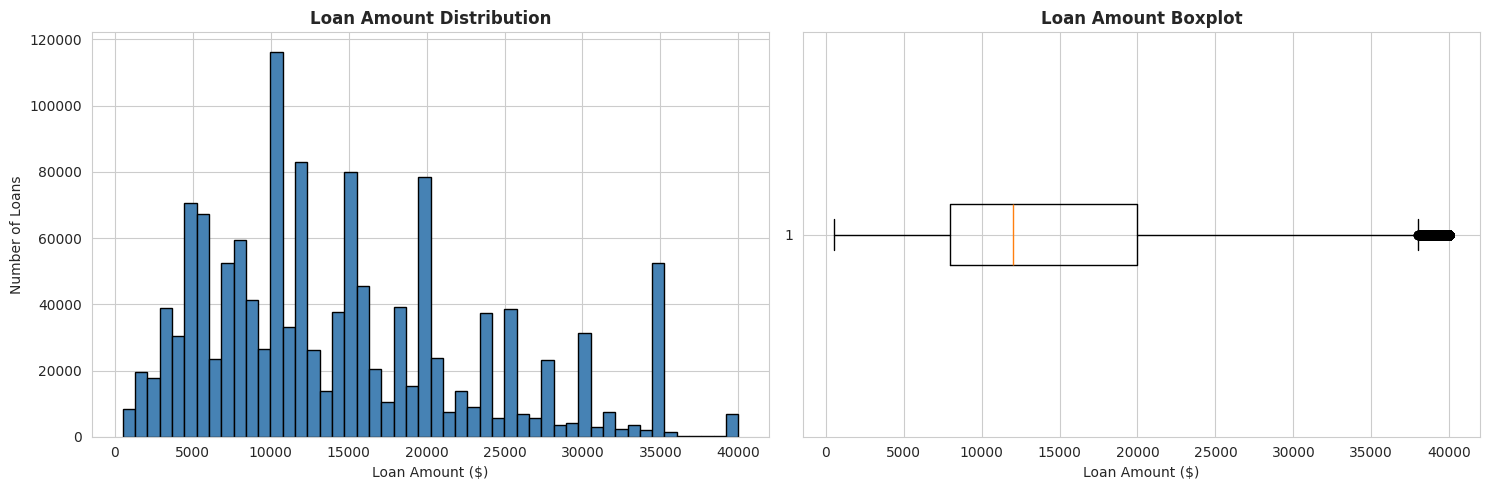

Min loan: $500
Max loan: $40,000
Average loan: $14,420
Median loan: $12,000


In [6]:
# Loan amount distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['loan_amnt'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Loan Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Loan Amount ($)')
axes[0].set_ylabel('Number of Loans')

# Boxplot
axes[1].boxplot(df['loan_amnt'], vert=False)
axes[1].set_title('Loan Amount Boxplot', fontweight='bold')
axes[1].set_xlabel('Loan Amount ($)')

plt.tight_layout()
plt.show()

print(f"Min loan: ${df['loan_amnt'].min():,.0f}")
print(f"Max loan: ${df['loan_amnt'].max():,.0f}")
print(f"Average loan: ${df['loan_amnt'].mean():,.0f}")
print(f"Median loan: ${df['loan_amnt'].median():,.0f}")

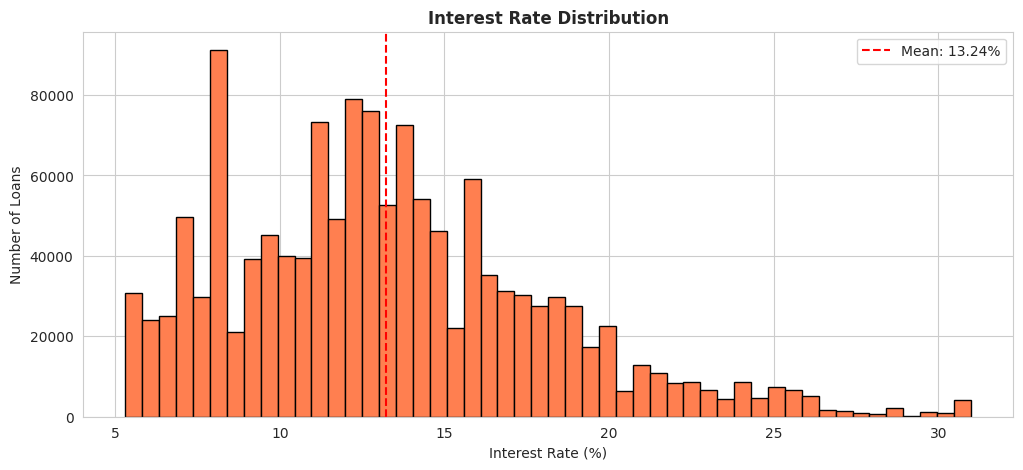

Lowest rate: 5.31%
Highest rate: 30.99%
Average rate: 13.24%


In [7]:
# Interest rate distribution
plt.figure(figsize=(12, 5))
plt.hist(df['int_rate'], bins=50, color='coral', edgecolor='black')
plt.title('Interest Rate Distribution', fontweight='bold')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Number of Loans')
plt.axvline(df['int_rate'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["int_rate"].mean():.2f}%')
plt.legend()
plt.show()

print(f"Lowest rate: {df['int_rate'].min():.2f}%")
print(f"Highest rate: {df['int_rate'].max():.2f}%")
print(f"Average rate: {df['int_rate'].mean():.2f}%")

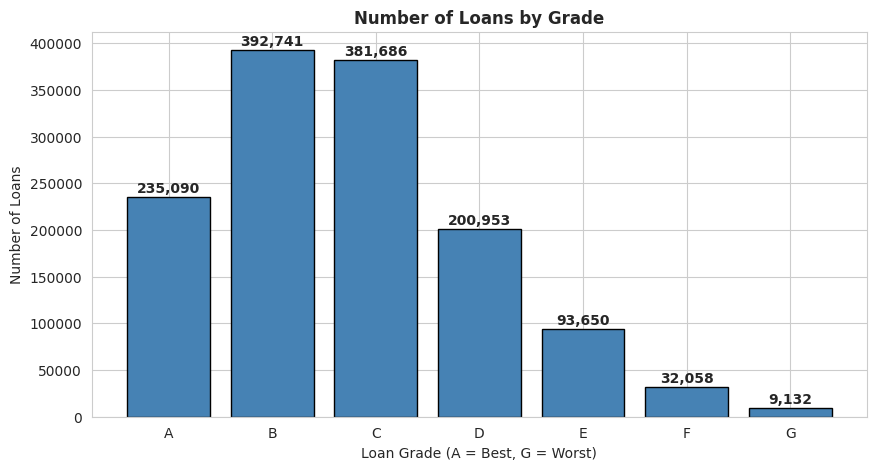

In [8]:
# Loan grade distribution
plt.figure(figsize=(10, 5))
grade_counts = df['grade'].value_counts().sort_index()
plt.bar(grade_counts.index, grade_counts.values, color='steelblue', edgecolor='black')
plt.title('Number of Loans by Grade', fontweight='bold')
plt.xlabel('Loan Grade (A = Best, G = Worst)')
plt.ylabel('Number of Loans')
for i, v in enumerate(grade_counts.values):
    plt.text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')
plt.show()

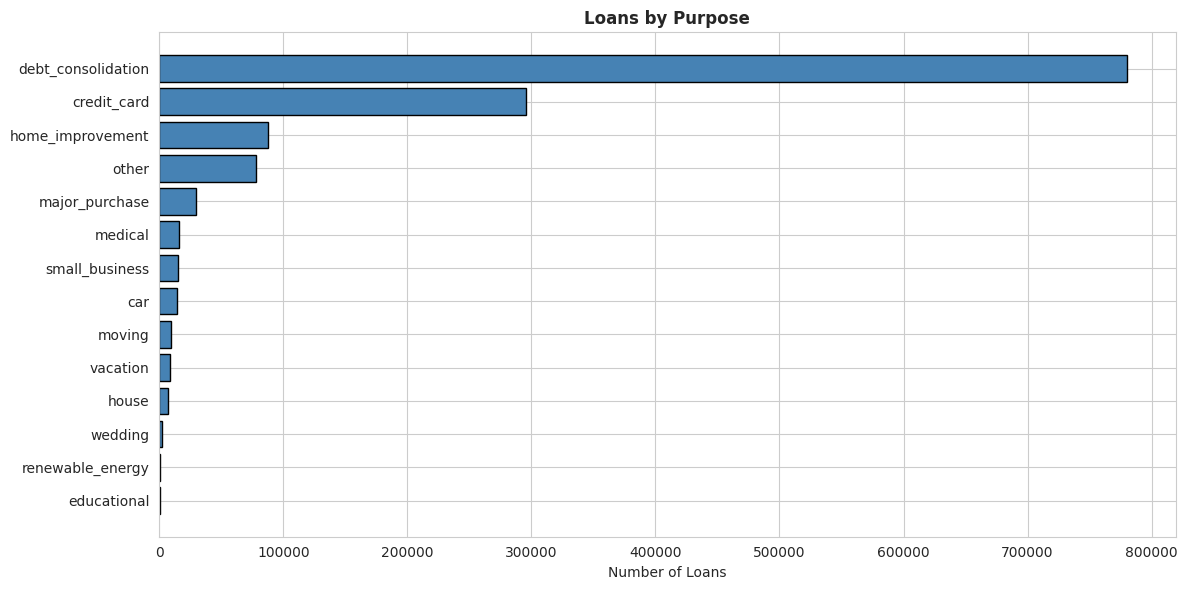

Top loan purposes:
purpose
debt_consolidation    780321
credit_card           295279
home_improvement       87504
other                  77875
major_purchase         29425
Name: count, dtype: int64


In [9]:
# Loan purpose distribution
plt.figure(figsize=(12, 6))
purpose_counts = df['purpose'].value_counts()
plt.barh(purpose_counts.index, purpose_counts.values, color='steelblue', edgecolor='black')
plt.title('Loans by Purpose', fontweight='bold')
plt.xlabel('Number of Loans')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top loan purposes:")
print(purpose_counts.head())

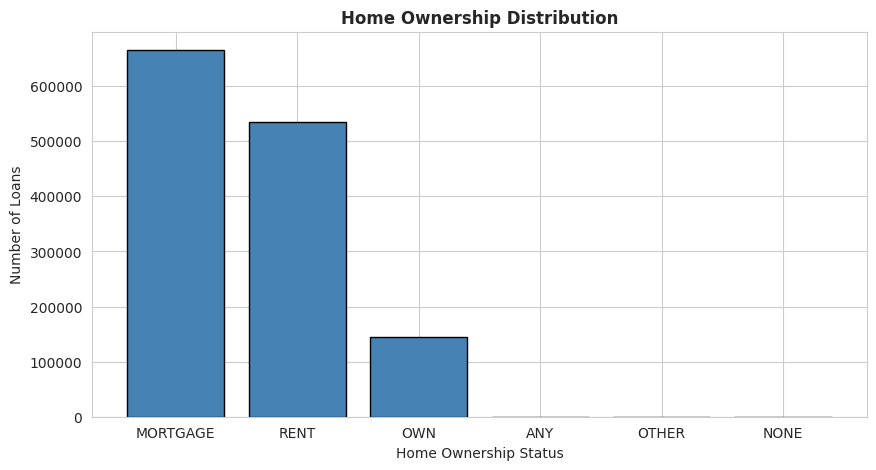

In [10]:
# Home ownership distribution
plt.figure(figsize=(10, 5))
home_counts = df['home_ownership'].value_counts()
plt.bar(home_counts.index, home_counts.values, color='steelblue', edgecolor='black')
plt.title('Home Ownership Distribution', fontweight='bold')
plt.xlabel('Home Ownership Status')
plt.ylabel('Number of Loans')
plt.show()

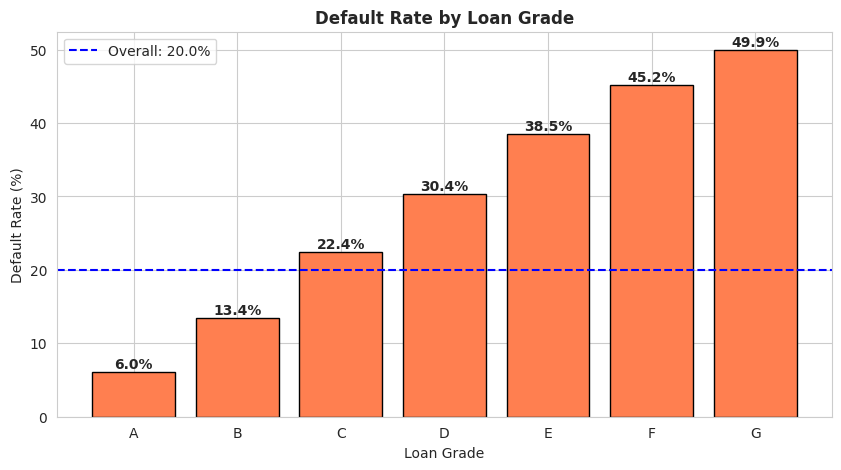

  Grade  Default_Rate  Loan_Count
0     A      6.040665      235090
1     B     13.385157      392741
2     C     22.439649      381686
3     D     30.382229      200953
4     E     38.478377       93650
5     F     45.202446       32058
6     G     49.934297        9132


In [11]:
# Default rate by grade
default_by_grade = df.groupby('grade')['target'].agg(['mean', 'count']).reset_index()
default_by_grade.columns = ['Grade', 'Default_Rate', 'Loan_Count']
default_by_grade['Default_Rate'] = default_by_grade['Default_Rate'] * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(default_by_grade['Grade'], default_by_grade['Default_Rate'],
                color='coral', edgecolor='black')
plt.title('Default Rate by Loan Grade', fontweight='bold')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.axhline(df['target'].mean()*100, color='blue', linestyle='--',
            label=f'Overall: {df["target"].mean()*100:.1f}%')

for bar, rate in zip(bars, default_by_grade['Default_Rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', fontweight='bold')

plt.legend()
plt.show()

print(default_by_grade)

### 🔍 Key Insight
- Grade A loans have lowest default rate (~5-6%)
- Grade G loans have highest default rate (~45%+)
- Loan grade is a **strong predictor** of default
- LendingClub's internal grading system is meaningful

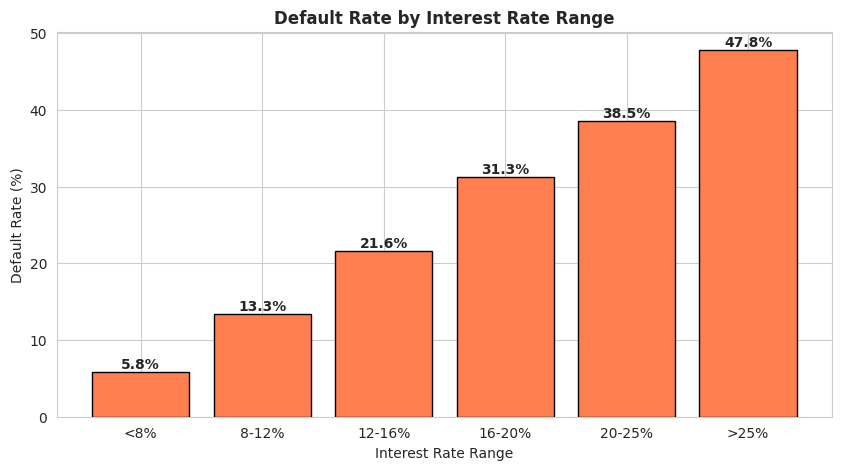

In [12]:
# Bin interest rates and check default rate
df['int_rate_bin'] = pd.cut(df['int_rate'],
                              bins=[0, 8, 12, 16, 20, 25, 35],
                              labels=['<8%', '8-12%', '12-16%', '16-20%', '20-25%', '>25%'])

default_by_rate = df.groupby('int_rate_bin')['target'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(default_by_rate.index.astype(str), default_by_rate.values,
                color='coral', edgecolor='black')
plt.title('Default Rate by Interest Rate Range', fontweight='bold')
plt.xlabel('Interest Rate Range')
plt.ylabel('Default Rate (%)')
for bar, rate in zip(bars, default_by_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', fontweight='bold')
plt.show()

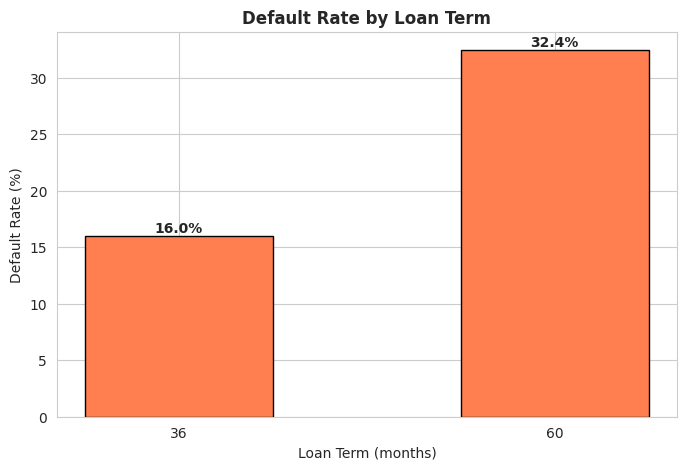

term
36    15.993448
60    32.445381
Name: target, dtype: float64


In [13]:
# Default by term (36 vs 60 months)
default_by_term = df.groupby('term')['target'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(default_by_term.index.astype(str), default_by_term.values,
                color='coral', edgecolor='black', width=0.5)
plt.title('Default Rate by Loan Term', fontweight='bold')
plt.xlabel('Loan Term (months)')
plt.ylabel('Default Rate (%)')
for bar, rate in zip(bars, default_by_term.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{rate:.1f}%', ha='center', fontweight='bold')
plt.show()

print(default_by_term)

### 🔍 Key Insight
- 60-month loans have nearly DOUBLE the default rate of 36-month loans
- Longer-term loans are riskier

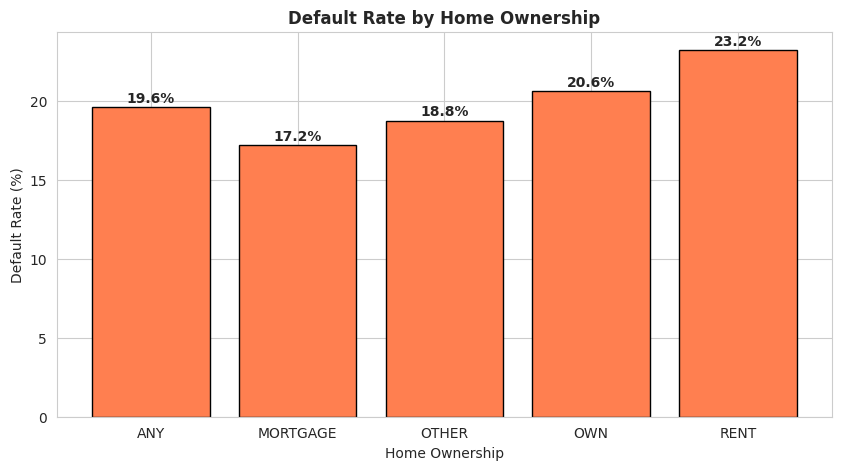

In [14]:
# Default by home ownership
default_by_home = df.groupby('home_ownership')['target'].mean() * 100
home_counts = df['home_ownership'].value_counts()

# Filter to only meaningful categories (count > 100)
valid_homes = home_counts[home_counts > 100].index
default_by_home = default_by_home[default_by_home.index.isin(valid_homes)]

plt.figure(figsize=(10, 5))
bars = plt.bar(default_by_home.index, default_by_home.values,
                color='coral', edgecolor='black')
plt.title('Default Rate by Home Ownership', fontweight='bold')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
for bar, rate in zip(bars, default_by_home.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{rate:.1f}%', ha='center', fontweight='bold')
plt.show()

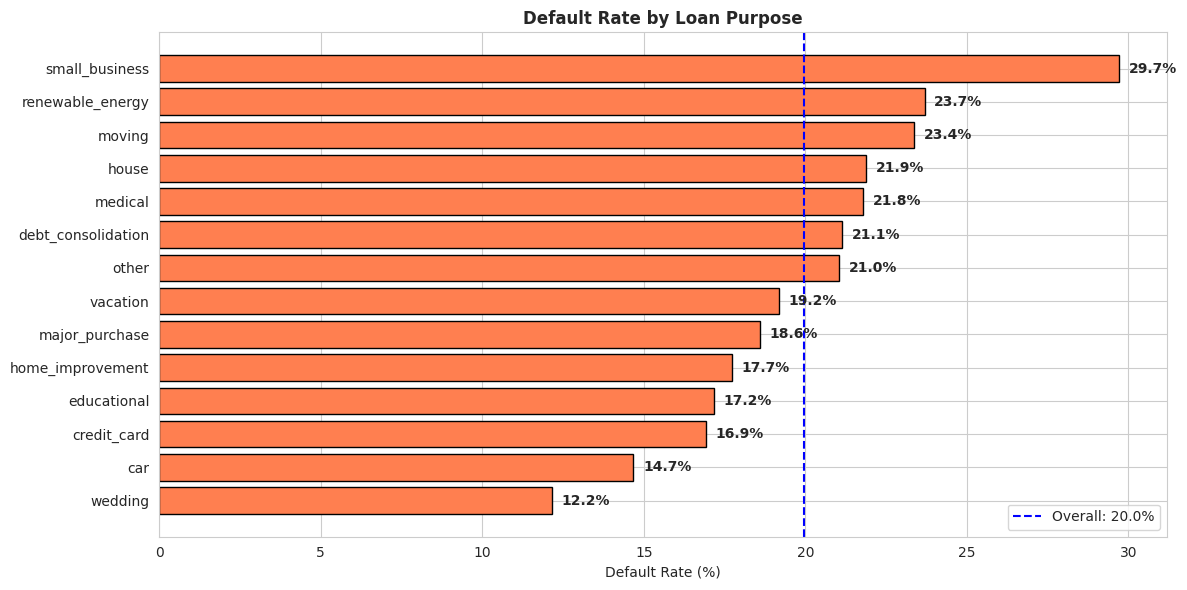

In [15]:
# Default by loan purpose
default_by_purpose = df.groupby('purpose')['target'].agg(['mean', 'count']).reset_index()
default_by_purpose.columns = ['Purpose', 'Default_Rate', 'Count']
default_by_purpose['Default_Rate'] = default_by_purpose['Default_Rate'] * 100
default_by_purpose = default_by_purpose.sort_values('Default_Rate', ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(default_by_purpose['Purpose'], default_by_purpose['Default_Rate'],
                 color='coral', edgecolor='black')
plt.title('Default Rate by Loan Purpose', fontweight='bold')
plt.xlabel('Default Rate (%)')

for bar, rate in zip(bars, default_by_purpose['Default_Rate']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontweight='bold')

plt.axvline(df['target'].mean()*100, color='blue', linestyle='--',
            label=f'Overall: {df["target"].mean()*100:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

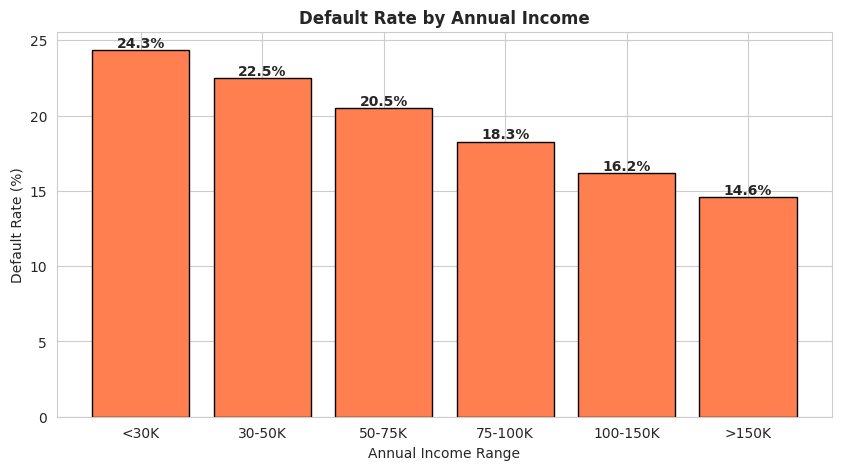

In [16]:
# Bin annual income
df['income_bin'] = pd.cut(df['annual_inc'],
                            bins=[0, 30000, 50000, 75000, 100000, 150000, 10000000],
                            labels=['<30K', '30-50K', '50-75K', '75-100K', '100-150K', '>150K'])

default_by_income = df.groupby('income_bin')['target'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(default_by_income.index.astype(str), default_by_income.values,
                color='coral', edgecolor='black')
plt.title('Default Rate by Annual Income', fontweight='bold')
plt.xlabel('Annual Income Range')
plt.ylabel('Default Rate (%)')
for bar, rate in zip(bars, default_by_income.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{rate:.1f}%', ha='center', fontweight='bold')
plt.show()

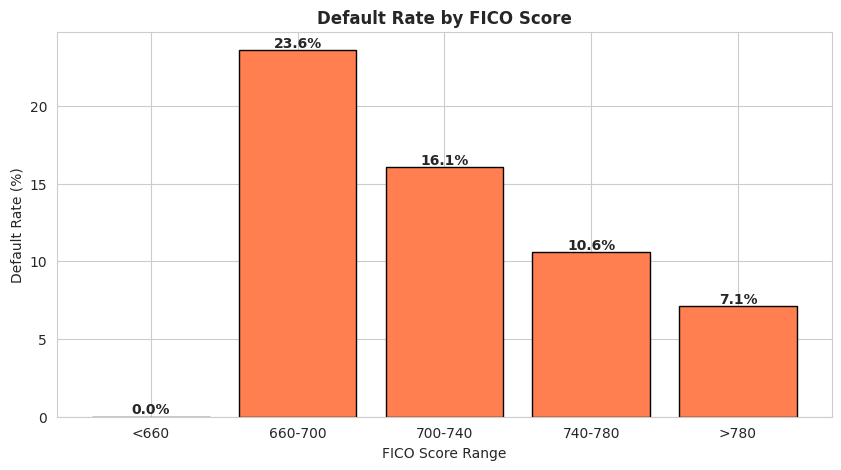

In [17]:
# Bin FICO scores
df['fico_bin'] = pd.cut(df['fico_avg'],
                          bins=[600, 660, 700, 740, 780, 850],
                          labels=['<660', '660-700', '700-740', '740-780', '>780'])

default_by_fico = df.groupby('fico_bin')['target'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(default_by_fico.index.astype(str), default_by_fico.values,
                color='coral', edgecolor='black')
plt.title('Default Rate by FICO Score', fontweight='bold')
plt.xlabel('FICO Score Range')
plt.ylabel('Default Rate (%)')
for bar, rate in zip(bars, default_by_fico.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{rate:.1f}%', ha='center', fontweight='bold')
plt.show()

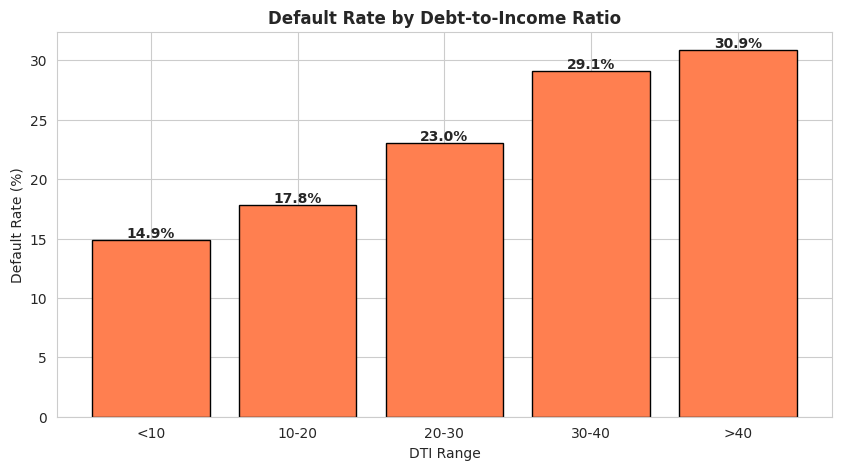

In [18]:
# Bin DTI
df['dti_bin'] = pd.cut(df['dti'],
                         bins=[0, 10, 20, 30, 40, 100],
                         labels=['<10', '10-20', '20-30', '30-40', '>40'])

default_by_dti = df.groupby('dti_bin')['target'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(default_by_dti.index.astype(str), default_by_dti.values,
                color='coral', edgecolor='black')
plt.title('Default Rate by Debt-to-Income Ratio', fontweight='bold')
plt.xlabel('DTI Range')
plt.ylabel('Default Rate (%)')
for bar, rate in zip(bars, default_by_dti.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{rate:.1f}%', ha='center', fontweight='bold')
plt.show()

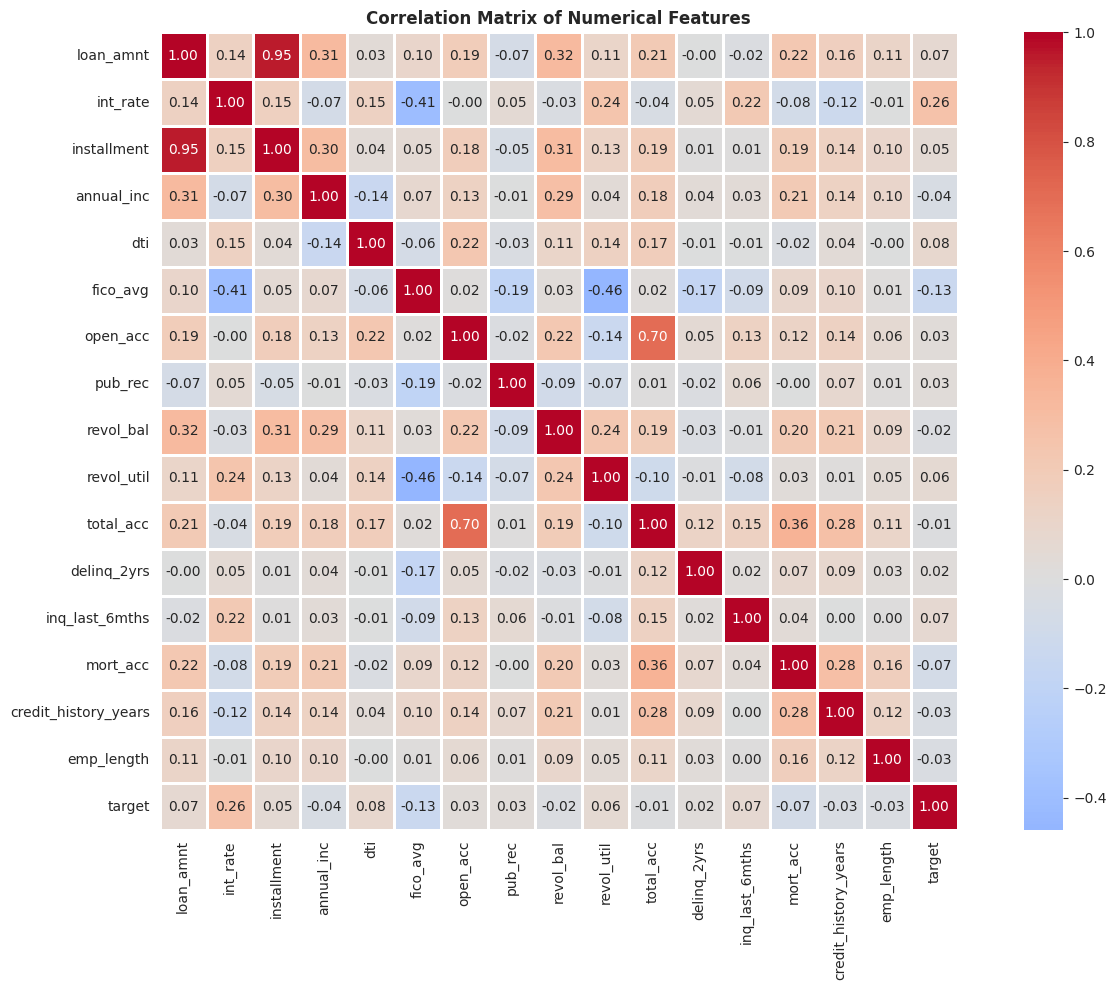

In [19]:
# Correlation of numerical features with target
numerical_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc',
                   'dti', 'fico_avg', 'open_acc', 'pub_rec', 'revol_bal',
                   'revol_util', 'total_acc', 'delinq_2yrs', 'inq_last_6mths',
                   'mort_acc', 'credit_history_years', 'emp_length', 'target']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

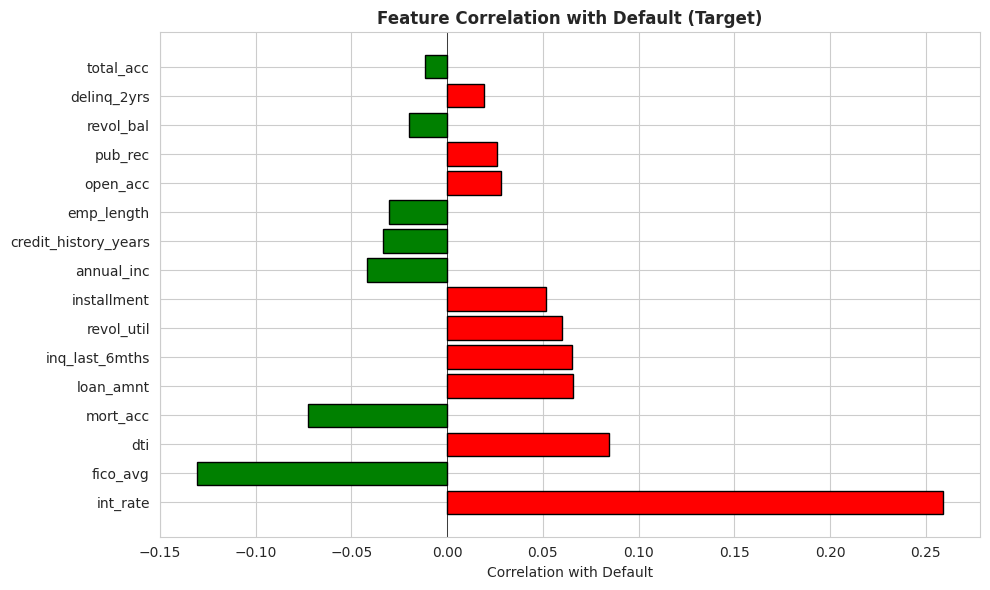

Top 10 features correlated with default:
int_rate                0.258792
fico_avg               -0.130683
dti                     0.084499
mort_acc               -0.072468
loan_amnt               0.065604
inq_last_6mths          0.065454
revol_util              0.060029
installment             0.051701
annual_inc             -0.041759
credit_history_years   -0.033418
Name: target, dtype: float64


In [20]:
# Sort features by absolute correlation with target
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
plt.title('Feature Correlation with Default (Target)', fontweight='bold')
plt.xlabel('Correlation with Default')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Top 10 features correlated with default:")
print(target_corr.head(10))

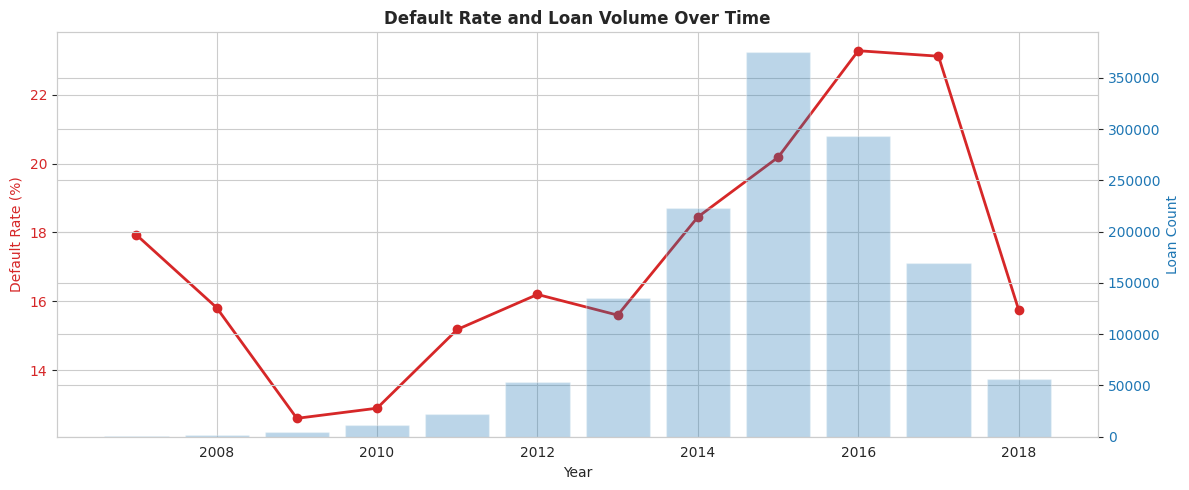

    Year  Default_Rate  Loan_Count
0   2007     17.928287         251
1   2008     15.813060        1562
2   2009     12.595420        4716
3   2010     12.890083       11536
4   2011     15.178859       21721
5   2012     16.197275       53367
6   2013     15.595976      134804
7   2014     18.449409      223102
8   2015     20.184798      375545
9   2016     23.283236      293095
10  2017     23.123449      169300
11  2018     15.746479       56311


In [21]:
# Default rate by year
df['issue_year'] = df['issue_d'].dt.year
default_by_year = df.groupby('issue_year')['target'].agg(['mean', 'count']).reset_index()
default_by_year.columns = ['Year', 'Default_Rate', 'Loan_Count']
default_by_year['Default_Rate'] = default_by_year['Default_Rate'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:red'
ax1.set_xlabel('Year')
ax1.set_ylabel('Default Rate (%)', color=color)
ax1.plot(default_by_year['Year'], default_by_year['Default_Rate'],
         color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Loan Count', color=color)
ax2.bar(default_by_year['Year'], default_by_year['Loan_Count'],
        color=color, alpha=0.3)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Default Rate and Loan Volume Over Time', fontweight='bold')
plt.tight_layout()
plt.show()

print(default_by_year)

## 🎯 Key EDA Insights

### Strongest Predictors of Default
1. **Loan Grade** - Default rate increases 8x from Grade A to Grade G
2. **Interest Rate** - Higher rates = higher default (strongly correlated)
3. **FICO Score** - Clear negative relationship with default
4. **Loan Term** - 60-month loans default 2x more than 36-month
5. **DTI Ratio** - Higher DTI = higher default risk

### Borrower Profiles
- **Low Risk**: Grade A, high FICO (>740), short-term loans, low DTI
- **High Risk**: Grade F/G, low FICO (<660), long-term loans, high DTI

### Business Recommendations
1. The bank's grading system is meaningful but can be enhanced with ML
2. 60-month loans require stricter approval criteria
3. DTI above 30% is a significant risk indicator
4. Annual income below $30K shows elevated default risk

### Modelling Strategy
- Features like grade, int_rate, fico_avg, term, dti are strong predictors
- These will likely be the most important features in our model
- We need to handle categorical variables (grade, purpose, home_ownership)